In [2]:
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

import numpy as np

import seaborn as sns
sns.set(color_codes=True)
sns.set_style("white")

In [2]:
np.random.uniform(low=0, high=1.0) # the chances ie probability of all numbers is equal (recall)

0.4681252191616998

#### now lets use it for coin flips

In [4]:
def flip(num = 1):
    """ generate a flip, pass n to generate n flips"""
    flips = []

    for i in range(num):
        num = np.random.uniform(low=0, high=1.0)
        if num > 0.5:
            flips.append('H')     # should be using 'yield' ie generators
        else:
            flips.append('T')
    return flips

In [4]:
flip()

['T']

In [5]:
flips = flip(10)
print(flips)

['T', 'T', 'T', 'T', 'T', 'T', 'T', 'T', 'H', 'T']


In [6]:
values, counts = np.unique(flips, return_counts=True)

In [7]:
values, counts

(array(['H', 'T'], dtype='<U1'), array([1, 9]))

### Reproducible Randomness
But there is a problem with this random flip using np.random  
it can cause Heisenbugs that can change occur under different  
time due to new random numbers every time

computers are psuedurandom ie we can predict what they will genrate\
to make it random we take a random  input from the real world i.e some noice sound measure\
and then we do oeperations e.g(modulus, power and multiplication) on them to produce random numbers\
this initial number is called seed

we can simply provide our own seed and regenerate that random numbers

### np.random.seed(0)

it will now take seed and produce random number then in next time it will use\
that random number as a seed

In [3]:
np.random.seed(1337) # 1337 is leet :)

In [30]:
np.random.uniform(low=0, high=1.0)

0.2620246750155817

In [32]:
flips = flip(10)
values, counts = np.unique(flips, return_counts=True)
print(flips)
print(values, counts)

['T', 'T', 'T', 'T', 'T', 'H', 'T', 'H', 'H', 'T']
['H' 'T'] [3 7]


## Probability of Flips

In [22]:
flips = ['H']

In [6]:
from collections import Counter, defaultdict

def get_freqs(flips):
    keys = Counter(flips).keys()
    vals = Counter(flips).values()

    #return dict(zip(keys, vals))  # bug: what if there is no 'H' or 'T'

    return defaultdict(int, dict(zip(keys, vals))) # deafoultdict
    
    

In [34]:
freqs = get_freqs(flips)
print(freqs)

defaultdict(<class 'int'>, {'T': 7, 'H': 3})


In [36]:
prob_t = freqs['T']/len(flips)
print(prob_t)

0.7


## Experiment: Prob calculated based on 1 flip upto N flips

In [7]:
maximum_flips = 1000

probs = []
for num_flips in range(1,maximum_flips):
    flips = flip(num_flips)
    freqs = get_freqs(flips)
    prob_h = freqs['H'] / len(flips)
    
    probs.append(prob_h)

In [42]:
print(freqs)

defaultdict(<class 'int'>, {'H': 502, 'T': 497})


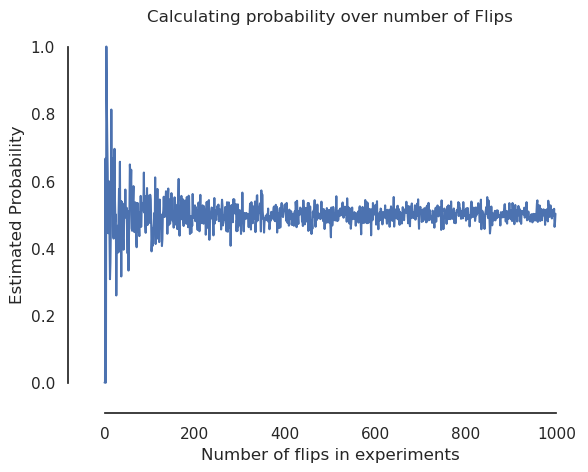

In [43]:
plt.plot(probs)
plt.ylabel("Estimated Probability")
plt.xlabel("Number of flips in experiments")
plt.title("Calculating probability over number of Flips")
sns.despine(offset=10, trim=True)
plt.show()

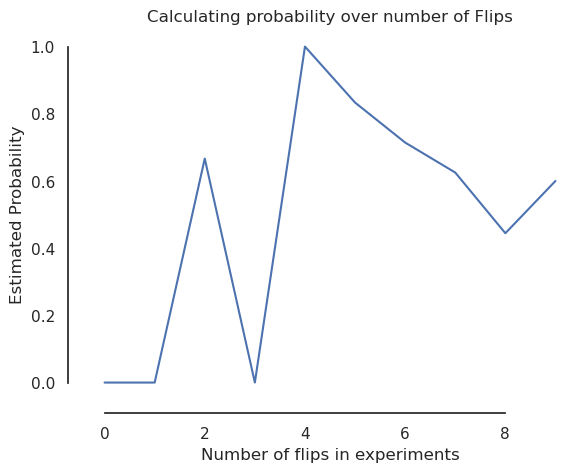

In [46]:
plt.plot(probs[:10])
plt.ylabel("Estimated Probability")
plt.xlabel("Number of flips in experiments")
plt.title("Calculating probability over number of Flips")
sns.despine(offset=10, trim=True)
plt.show()

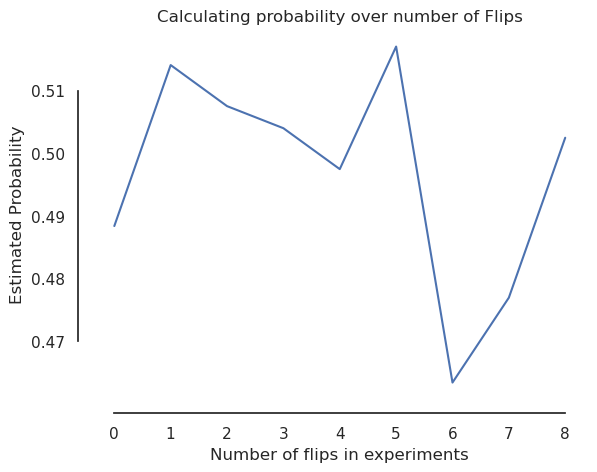

In [47]:
plt.plot(probs[maximum_flips-10:])
plt.ylabel("Estimated Probability")
plt.xlabel("Number of flips in experiments")
plt.title("Calculating probability over number of Flips")
sns.despine(offset=10, trim=True)
plt.show()

we can see as no experiments increases the calculed prob tends to go\
near the actual value but exact value is acheived very small no of times\
so, we can't say tha this many number of experiments are enough for estimating prob

#### Bokeh for interactive plots

In [48]:
!pip install bokeh

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.4/6.4 MB 44.1 kB/s  0:03:02a 0:00:03m eta 0:00:11
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [bokeh]━━━━━━━━━━━━ 2/3 [bokeh]


In [8]:
from bokeh.io import show, output_notebook
from bokeh.plotting import figure

output_notebook()  # show bokh output on notebook cell

Loading BokehJS ...

In [9]:
p = figure(title="Sample Plot in Bokeh",
           x_axis_label='Number of flips in Experiment',
           y_axis_label='Estimated Probability',
           width=500, height=380)

In [10]:
# Add a line renderer with legend and line thickness
x = list(range(1, maximum_flips))
p.line(x=x, y=probs)

show(p)

now we can interact with plot and analyze better by seeing axis values 